# Chayote Freshness Clustering Based on Image Color and Texture Features

Notebook ini mengelompokkan (clustering) citra buah labu siam (chayote) berdasarkan fitur warna (RGB, HSV) dan tekstur (Local Binary Pattern) menggunakan K-Means, sebagai eksplorasi awal untuk melihat apakah karakteristik visual buah dapat membentuk kelompok yang berbeda.

## 1. Rumusan Masalah dan Tujuan

**Latar Belakang:**
Kesegaran buah labu siam dapat memengaruhi kualitas dan daya jualnya. Secara visual, buah yang lebih segar dan yang mulai layu/rusak seringkali memiliki perbedaan warna dan tekstur permukaan yang dapat diekstraksi dari citra.

**Rumusan Masalah:**
- Apakah fitur warna (RGB, HSV) dan tekstur (LBP) yang diekstraksi dari citra buah labu siam dapat membentuk kelompok (cluster) yang berbeda secara visual?
- Berapa jumlah cluster yang paling optimal untuk mengelompokkan data ini?

**Tujuan Analisis:**
1. Mengekstraksi fitur warna dan tekstur dari kumpulan citra buah labu siam.
2. Melakukan clustering menggunakan K-Means untuk mengelompokkan citra berdasarkan fitur tersebut.
3. Mengevaluasi kualitas hasil clustering menggunakan Silhouette Score dan Davies-Bouldin Index.

## 2. Menghubungkan ke Google Drive

Dataset citra disimpan di Google Drive karena ukurannya tidak praktis untuk disimpan langsung. Dataset yang digunakan merupakan gabungan foto labu siam dari 3 anggota kelompok (total 2069 foto), yang digabungkan menjadi satu folder sebelum diproses lebih lanjut.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd

BASE_DIR = '/content/drive/MyDrive/Data mining lanjut'

DATASET_FOLDERS = {
    'Irsyad': 'Dataset - Irsyad',
    'Ilza': 'Dataset - Ilza',
    'Danu': 'Dataset - Danu ',
    'DML': 'Dataset-DML'
}

JPEG_DIR = os.path.join(BASE_DIR, 'Dataset Gabungan JPG')
FEATURE_CSV = os.path.join(BASE_DIR, 'fitur_labu_siam.csv')

print("Isi folder utama:", os.listdir(BASE_DIR))

total_file = 0
for nama, folder in DATASET_FOLDERS.items():
    path = os.path.join(BASE_DIR, folder)
    if os.path.exists(path):
        jumlah = len(os.listdir(path))
        total_file += jumlah
        print(f"\n{nama} ({folder}): {jumlah} file")
    else:
        print(f"\n{nama} ({folder}): FOLDER TIDAK DITEMUKAN - cek nama persis di Drive")

print(f"\nTotal seluruh file (sebelum filter tipe file): {total_file}")

Isi folder utama: ['Dataset-DML', 'Dataset - Danu ', 'Dataset - Ilza', 'Dataset - Irsyad', 'Dataset Gabungan JPG', 'fitur_labu_siam.csv', 'cluster_labu_siam_k2_hasil.csv']

Irsyad (Dataset - Irsyad): 118 file

Ilza (Dataset - Ilza): 1017 file

Danu (Dataset - Danu ): 326 file

DML (Dataset-DML): 608 file

Total seluruh file (sebelum filter tipe file): 2069


## 3. Konversi Format Citra (HEIC ke JPEG)

Sebagian foto diambil dalam format HEIC (format default kamera iPhone), yang perlu dikonversi ke JPEG terlebih dahulu agar dapat diproses dengan OpenCV.

In [3]:
!pip install pyheif pillow -q

import pyheif
from PIL import Image

os.makedirs(JPEG_DIR, exist_ok=True)

converted_count = 0
copied_count = 0

for nama, folder in DATASET_FOLDERS.items():
    source_folder = os.path.join(BASE_DIR, folder)
    if not os.path.exists(source_folder):
        continue

    for file_name in os.listdir(source_folder):
        source_path = os.path.join(source_folder, file_name)
        base_name, ext = os.path.splitext(file_name)
        new_name = f"{nama}_{base_name}"

        if file_name.lower().endswith('.heic'):
            image = pyheif.read(source_path)
            pil_img = Image.frombytes(image.mode, image.size, image.data, "raw", image.mode)
            output_path = os.path.join(JPEG_DIR, new_name + '.jpg')
            pil_img.save(output_path, format="JPEG")
            converted_count += 1

        elif file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            output_path = os.path.join(JPEG_DIR, new_name + ext)
            Image.open(source_path).convert("RGB").save(output_path, format="JPEG")
            copied_count += 1

print(f"Konversi selesai. {converted_count} file HEIC dikonversi ke JPEG.")
print(f"{copied_count} file JPEG/PNG yang sudah ada langsung disalin.")
print(f"Total citra di folder gabungan: {len(os.listdir(JPEG_DIR))}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 75.7 MB/s eta 0:00:00
Konversi selesai. 2067 file HEIC dikonversi ke JPEG.
2 file JPEG/PNG yang sudah ada langsung disalin.
Total citra di folder gabungan: 2069


## 4. Ekstraksi Fitur Citra

Untuk setiap citra, dilakukan:
1. Resize ke ukuran seragam (256x256)
2. Segmentasi buah dari background menggunakan thresholding warna HSV
3. Ekstraksi fitur warna - nilai rata-rata channel RGB dan HSV pada area buah (setelah segmentasi)
4. Ekstraksi fitur tekstur - Local Binary Pattern (LBP), untuk menangkap pola permukaan buah (misalnya bercak atau tekstur kulit yang berubah seiring tingkat kesegaran)

In [4]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.feature import local_binary_pattern

def resize_gambar(image, target_size=(256, 256)):
    return cv2.resize(image, target_size)

def segmentasi_buah(image_bgr):
    image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    lower_hsv = np.array([10, 40, 40])
    upper_hsv = np.array([180, 255, 255])
    mask = cv2.inRange(image_hsv, lower_hsv, upper_hsv)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return mask

def ekstrak_fitur(image_path):
    image_bgr = cv2.imread(image_path)
    image_resized = resize_gambar(image_bgr)
    image_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)
    image_hsv = cv2.cvtColor(image_resized, cv2.COLOR_BGR2HSV)
    image_gray = cv2.cvtColor(image_resized, cv2.COLOR_BGR2GRAY)
    mask = segmentasi_buah(image_resized)

    buah_rgb = cv2.bitwise_and(image_rgb, image_rgb, mask=mask)
    buah_hsv = cv2.bitwise_and(image_hsv, image_hsv, mask=mask)
    buah_gray = cv2.bitwise_and(image_gray, image_gray, mask=mask)

    buah_rgb_pixels = buah_rgb[mask > 0]
    buah_hsv_pixels = buah_hsv[mask > 0]

    mean_r = np.mean(buah_rgb_pixels[:, 0])
    mean_g = np.mean(buah_rgb_pixels[:, 1])
    mean_b = np.mean(buah_rgb_pixels[:, 2])
    mean_h = np.mean(buah_hsv_pixels[:, 0])
    mean_s = np.mean(buah_hsv_pixels[:, 1])
    mean_v = np.mean(buah_hsv_pixels[:, 2])

    if np.max(buah_gray) > 0:
        radius = 1
        n_points = 8 * radius
        lbp = local_binary_pattern(buah_gray, n_points, radius, method='uniform')
        lbp_masked = lbp[mask > 0]
        n_bins = int(lbp.max() + 1)
        hist, _ = np.histogram(lbp_masked, bins=n_bins, range=(0, n_bins), density=True)
        lbp_mean = np.mean(hist)
        lbp_std = np.std(hist)
    else:
        lbp_mean, lbp_std = 0.0, 0.0

    return {
        'filename': os.path.basename(image_path),
        'mean_r': round(mean_r, 5), 'mean_g': round(mean_g, 5), 'mean_b': round(mean_b, 5),
        'mean_h': round(mean_h, 5), 'mean_s': round(mean_s, 5), 'mean_v': round(mean_v, 5),
        'lbp_mean': round(lbp_mean, 5), 'lbp_std': round(lbp_std, 5)
    }

def tampilkan_visualisasi_contoh(image_path):
    image_bgr = cv2.imread(image_path)
    image_resized = resize_gambar(image_bgr)
    image_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)
    image_gray = cv2.cvtColor(image_resized, cv2.COLOR_BGR2GRAY)
    mask = segmentasi_buah(image_resized)
    buah_rgb = cv2.bitwise_and(image_rgb, image_rgb, mask=mask)

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle("Contoh Proses Ekstraksi Fitur Citra", fontsize=14)
    axes[0].imshow(image_rgb); axes[0].set_title("Citra RGB"); axes[0].axis('off')
    axes[1].imshow(image_gray, cmap='gray'); axes[1].set_title("Citra Grayscale"); axes[1].axis('off')
    axes[2].imshow(mask, cmap='gray'); axes[2].set_title("Hasil Segmentasi (Mask)"); axes[2].axis('off')
    axes[3].imshow(buah_rgb); axes[3].set_title("Buah Tersegmentasi"); axes[3].axis('off')
    plt.tight_layout()
    plt.show()

Jumlah citra ditemukan: 2069


Mengekstraksi fitur:   0%|          | 0/2069 [00:00<?, ?it/s]

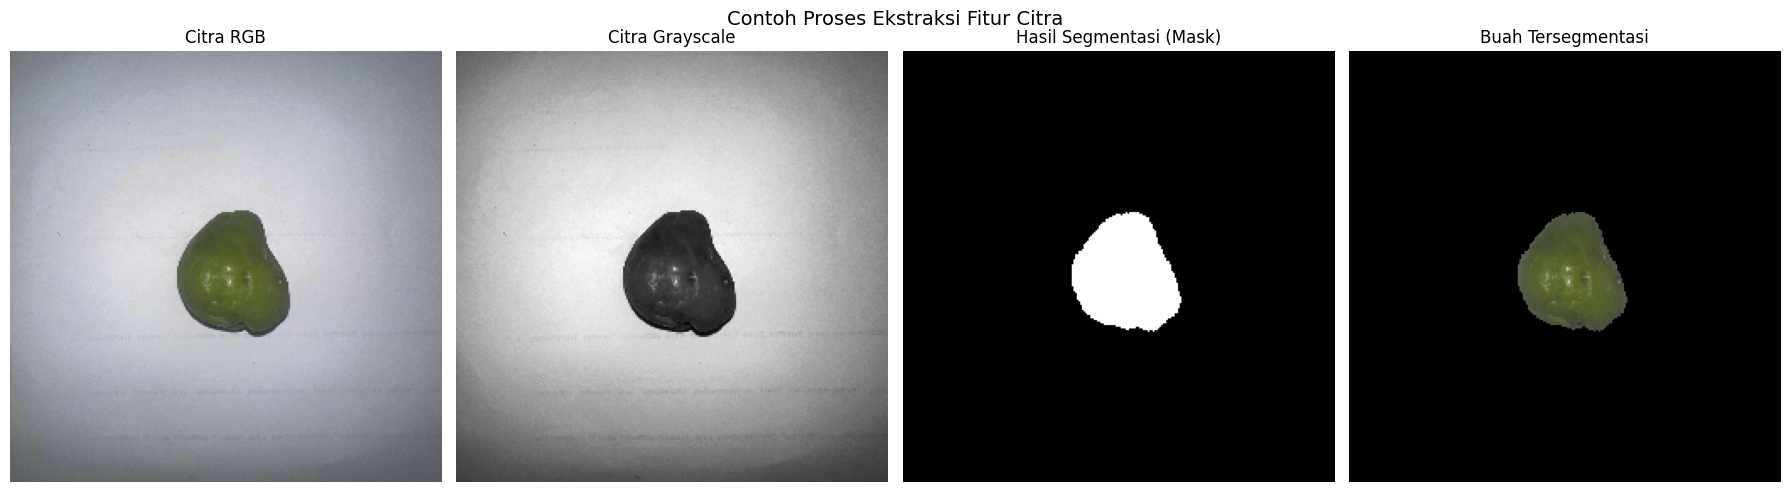

Mengekstraksi fitur: 100%|██████████| 2069/2069 [04:14<00:00,  8.12it/s]



Fitur (warna + tekstur) berhasil disimpan di: /content/drive/MyDrive/Data mining lanjut/fitur_labu_siam.csv


,filename,mean_r,mean_g,mean_b,mean_h,mean_s,mean_v,lbp_mean,lbp_std
0,Ilza_IMG_8677.jpg,83.51684,93.40980,54.38425,38.04781,105.17769,93.45340,0.1,0.03315
1,Ilza_IMG_8675.jpg,87.46768,98.07777,55.00438,38.37832,109.28638,98.07881,0.1,0.03041
2,Ilza_IMG_8633.jpg,88.26809,98.36913,52.18672,37.19984,116.85325,98.38471,0.1,0.02867
3,Ilza_IMG_8658.jpg,88.17417,97.25420,52.97740,36.65810,114.49513,97.26332,0.1,0.03477
4,Ilza_IMG_8593.jpg,90.81779,102.41408,53.69626,37.77228,119.24018,102.43149,0.1,0.02959


In [5]:
image_files = [f for f in os.listdir(JPEG_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
full_paths = [os.path.join(JPEG_DIR, fname) for fname in image_files]

print(f"Jumlah citra ditemukan: {len(full_paths)}")

data = []
for idx, img_path in enumerate(tqdm(full_paths, desc='Mengekstraksi fitur')):
    fitur = ekstrak_fitur(img_path)
    data.append(fitur)
    if idx == 0:
        tampilkan_visualisasi_contoh(img_path)

df = pd.DataFrame(data)
df.to_csv(FEATURE_CSV, index=False)
print(f"\nFitur (warna + tekstur) berhasil disimpan di: {FEATURE_CSV}")
df.head()

## 5. Data Understanding: Statistik Fitur yang Diekstraksi

In [6]:
feature_cols = ['mean_r', 'mean_g', 'mean_b', 'mean_h', 'mean_s', 'mean_v', 'lbp_mean', 'lbp_std']
print("Statistik deskriptif fitur:")
df[feature_cols].describe()

Statistik deskriptif fitur:


,mean_r,mean_g,mean_b,mean_h,mean_s,mean_v,lbp_mean,lbp_std
count,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2.069000e+03,2069.000000
mean,82.641704,90.926319,42.239918,35.304715,138.752319,91.749084,1.000000e-01,0.033846
std,15.906765,16.401252,12.144969,4.301969,26.296288,15.988251,3.622978e-15,0.005994
min,41.852980,48.050510,10.789780,22.662370,56.163640,48.369670,1.000000e-01,0.022850
25%,72.826260,80.022670,35.468070,33.518930,125.778160,80.895010,1.000000e-01,0.029070
50%,82.381420,92.234900,42.868300,35.836820,136.808450,92.735570,1.000000e-01,0.032830
75%,92.005860,101.442800,50.845440,37.771890,146.480250,102.042780,1.000000e-01,0.037920
max,143.810230,147.746320,78.396730,86.374790,217.848590,147.971090,1.000000e-01,0.066770


## 6. Preprocessing: Standarisasi Fitur

Fitur distandarisasi (mean=0, std=1) agar tidak ada fitur yang mendominasi perhitungan jarak pada K-Means hanya karena skalanya lebih besar.

In [7]:
from sklearn.preprocessing import StandardScaler

features_all = ['mean_r', 'mean_g', 'mean_b', 'mean_h', 'mean_s', 'mean_v', 'lbp_std']
X_all = df[features_all].values

scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

print("Fitur yang digunakan:", features_all)
print("Ukuran data setelah scaling:", X_all_scaled.shape)

Fitur yang digunakan: ['mean_r', 'mean_g', 'mean_b', 'mean_h', 'mean_s', 'mean_v', 'lbp_std']
Ukuran data setelah scaling: (2069, 7)


## 7. Menentukan Jumlah Cluster (k) yang Optimal

Sebelum menetapkan jumlah cluster, beberapa nilai k diuji terlebih dahulu menggunakan Silhouette Score, agar pemilihan k tidak sembarangan/tanpa dasar.

k=2: Silhouette Score = 0.3886
k=3: Silhouette Score = 0.2707
k=4: Silhouette Score = 0.3046
k=5: Silhouette Score = 0.3328
k=6: Silhouette Score = 0.3542


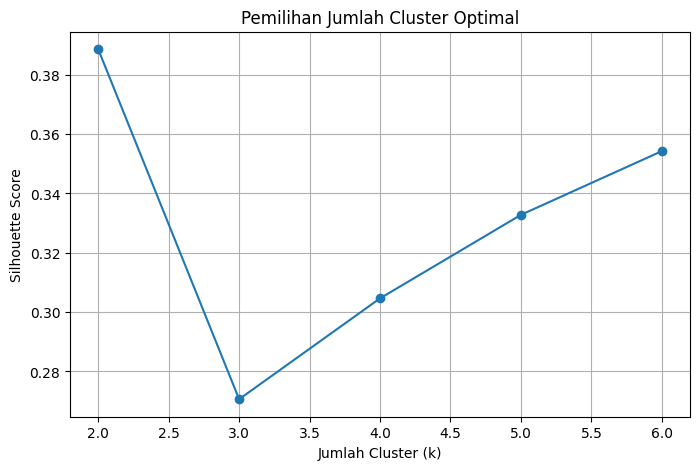


Jumlah cluster optimal berdasarkan Silhouette Score: k=2


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 7)
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_all_scaled)
    score = silhouette_score(X_all_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}: Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_scores, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Pemilihan Jumlah Cluster Optimal')
plt.grid(True)
plt.show()

best_k = list(k_range)[int(np.argmax(silhouette_scores))]
print(f"\nJumlah cluster optimal berdasarkan Silhouette Score: k={best_k}")

## 8. Clustering dengan K-Means (Seluruh Fitur)

Menggunakan seluruh fitur warna dan tekstur yang diekstraksi.

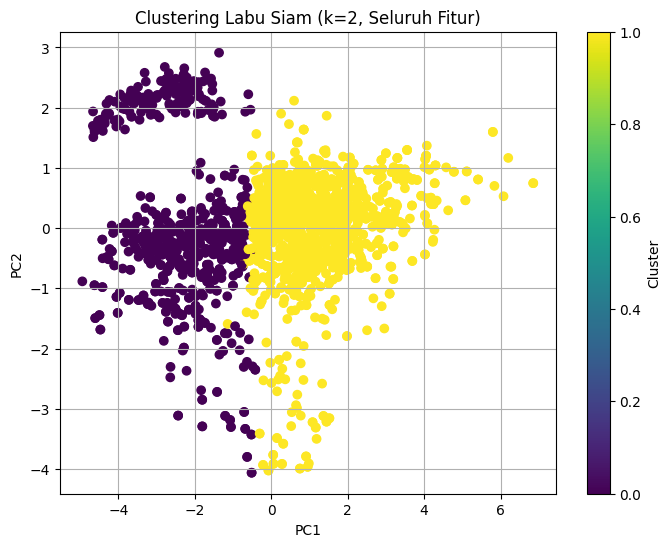

Silhouette Score: 0.3886


In [9]:
kmeans_all = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster_all_features'] = kmeans_all.fit_predict(X_all_scaled)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_all_scaled)
df['PC1'], df['PC2'] = pcs[:, 0], pcs[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(df['PC1'], df['PC2'], c=df['cluster_all_features'], cmap='viridis')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'Clustering Labu Siam (k={best_k}, Seluruh Fitur)')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

sil_all = silhouette_score(X_all_scaled, df['cluster_all_features'])
dbi_all = davies_bouldin_score(X_all_scaled, df['cluster_all_features']) if 'davies_bouldin_score' in dir() else None
print(f"Silhouette Score: {sil_all:.4f}")

In [10]:
from sklearn.metrics import davies_bouldin_score

dbi_all = davies_bouldin_score(X_all_scaled, df['cluster_all_features'])
print(f"Davies-Bouldin Index (Seluruh Fitur): {dbi_all:.4f}")

Davies-Bouldin Index (Seluruh Fitur): 1.1219


## 9. Eksperimen Pembanding: Clustering Tanpa Fitur mean_r dan mean_b

Sebagai perbandingan, dicoba juga clustering dengan mengeluarkan `mean_r` dan `mean_b`, untuk melihat apakah fitur warna Hue/Saturation/Value saja sudah cukup membedakan cluster tanpa fitur RGB mentah.

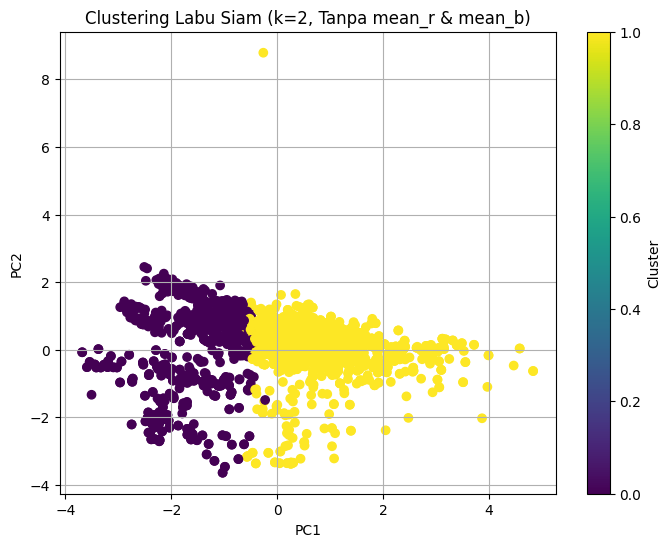

Silhouette Score: 0.3921
Davies-Bouldin Index: 1.2104


In [11]:
features_reduced = ['mean_g', 'mean_h', 'mean_s', 'mean_v']
X_reduced = df[features_reduced].values
X_reduced_scaled = scaler.fit_transform(X_reduced)

kmeans_reduced = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster_reduced_features'] = kmeans_reduced.fit_predict(X_reduced_scaled)

pca2 = PCA(n_components=2)
pcs2 = pca2.fit_transform(X_reduced_scaled)
df['PC1_reduced'], df['PC2_reduced'] = pcs2[:, 0], pcs2[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(df['PC1_reduced'], df['PC2_reduced'], c=df['cluster_reduced_features'], cmap='viridis')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'Clustering Labu Siam (k={best_k}, Tanpa mean_r & mean_b)')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

sil_reduced = silhouette_score(X_reduced_scaled, df['cluster_reduced_features'])
dbi_reduced = davies_bouldin_score(X_reduced_scaled, df['cluster_reduced_features'])
print(f"Silhouette Score: {sil_reduced:.4f}")
print(f"Davies-Bouldin Index: {dbi_reduced:.4f}")

## 10. Perbandingan Kedua Eksperimen

In [12]:
comparison = pd.DataFrame({
    'Eksperimen': ['Seluruh Fitur', 'Tanpa mean_r & mean_b'],
    'Silhouette Score': [sil_all, sil_reduced],
    'Davies-Bouldin Index': [dbi_all, dbi_reduced]
})
print(comparison.to_string(index=False))

           Eksperimen  Silhouette Score  Davies-Bouldin Index
        Seluruh Fitur          0.388574              1.121905
Tanpa mean_r & mean_b          0.392098              1.210435


In [13]:
output_path = os.path.join(BASE_DIR, f'cluster_labu_siam_k{best_k}_hasil.csv')
df.to_csv(output_path, index=False)
print(f"Hasil clustering lengkap disimpan di: {output_path}")
df[['filename'] + feature_cols + ['cluster_all_features', 'cluster_reduced_features']].head(10)

Hasil clustering lengkap disimpan di: /content/drive/MyDrive/Data mining lanjut/cluster_labu_siam_k2_hasil.csv


,filename,mean_r,mean_g,mean_b,mean_h,mean_s,mean_v,lbp_mean,lbp_std,cluster_all_features,cluster_reduced_features
0,Ilza_IMG_8677.jpg,83.51684,93.40980,54.38425,38.04781,105.17769,93.45340,0.1,0.03315,1,1
1,Ilza_IMG_8675.jpg,87.46768,98.07777,55.00438,38.37832,109.28638,98.07881,0.1,0.03041,1,1
2,Ilza_IMG_8633.jpg,88.26809,98.36913,52.18672,37.19984,116.85325,98.38471,0.1,0.02867,1,1
3,Ilza_IMG_8658.jpg,88.17417,97.25420,52.97740,36.65810,114.49513,97.26332,0.1,0.03477,1,1
4,Ilza_IMG_8593.jpg,90.81779,102.41408,53.69626,37.77228,119.24018,102.43149,0.1,0.02959,1,1
5,Ilza_IMG_8580.jpg,90.84714,104.57332,47.89922,37.90261,135.81087,104.58673,0.1,0.03912,1,1
6,Ilza_IMG_8513.jpg,91.86671,102.88705,51.43820,37.70213,125.97247,103.00610,0.1,0.03400,1,1
7,Ilza_IMG_8659.jpg,91.43563,100.89907,53.94243,36.51420,117.02625,100.92474,0.1,0.03324,1,1
8,Ilza_IMG_8652.jpg,76.59700,87.78652,48.76860,38.94312,112.98208,87.94936,0.1,0.03884,1,1
9,Ilza_IMG_8532.jpg,82.96692,94.04849,49.65708,37.91370,119.26074,94.10787,0.1,0.03851,1,1


## 11. Kesimpulan dan Keterbatasan

**Kesimpulan:**
1. Fitur warna dan tekstur yang diekstraksi dari citra buah labu siam berhasil dikelompokkan menjadi beberapa cluster menggunakan K-Means, dengan jumlah cluster ditentukan secara objektif melalui Silhouette Score.
2. Perbandingan antara menggunakan seluruh fitur vs. mengeluarkan fitur RGB mentah (mean_r, mean_b) menunjukkan performa clustering yang dapat dibandingkan melalui Silhouette Score dan Davies-Bouldin Index.

**Keterbatasan:**
- Dataset ini belum memiliki label ground-truth kesegaran (segar/tidak segar berdasarkan penilaian manual/pakar). Karena itu, cluster yang terbentuk mencerminkan pengelompokan berdasarkan kemiripan visual (warna dan tekstur), bukan validasi langsung terhadap tingkat kesegaran sebenarnya.
- Untuk mengetahui apakah cluster yang terbentuk benar-benar berkorespondensi dengan kesegaran (misalnya cluster 0 = segar, cluster 1 = tidak segar), diperlukan verifikasi manual terhadap sampel citra pada masing-masing cluster.
- Karena foto berasal dari 3 kamera/HP anggota kelompok yang berbeda, ada kemungkinan variasi pencahayaan dan white balance antar sumber foto turut memengaruhi fitur warna yang diekstraksi, bukan semata-mata karena perbedaan tingkat kesegaran buah. Hal ini perlu diperhitungkan saat menginterpretasikan hasil cluster.

**Rekomendasi Pengembangan Lanjutan:**
- Mengumpulkan label kesegaran (misalnya dari penilaian visual manual/pakar atau berdasarkan waktu penyimpanan buah) untuk setiap citra, agar project ini dapat dikembangkan menjadi model klasifikasi supervised (KNN, Random Forest, dll.) yang benar-benar memprediksi tingkat kesegaran.
- Melakukan standarisasi kondisi pengambilan foto (pencahayaan, jarak, latar belakang) di pengumpulan data berikutnya, agar variasi antar sumber foto tidak memengaruhi hasil ekstraksi fitur warna.
- Mengeksplorasi fitur tambahan (misalnya tekstur GLCM atau deep feature dari CNN pretrained) untuk menangkap karakteristik visual yang lebih kaya.